# ==============================================
#  MULTIPLE LINEAR REGRESSION - 50 STARTUPS
# ==============================================


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("/content/50_Startups.csv")

print("Dataset Loaded Successfully!\n")

Dataset Loaded Successfully!



In [4]:
print(df.head())


   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94


In [5]:
print("\nStep 3: Data Understanding...\n")

print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())


Step 3: Data Understanding...

Shape of dataset: (50, 5)

Columns:
 Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

Data Types:
 R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

Null Values:
 R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64


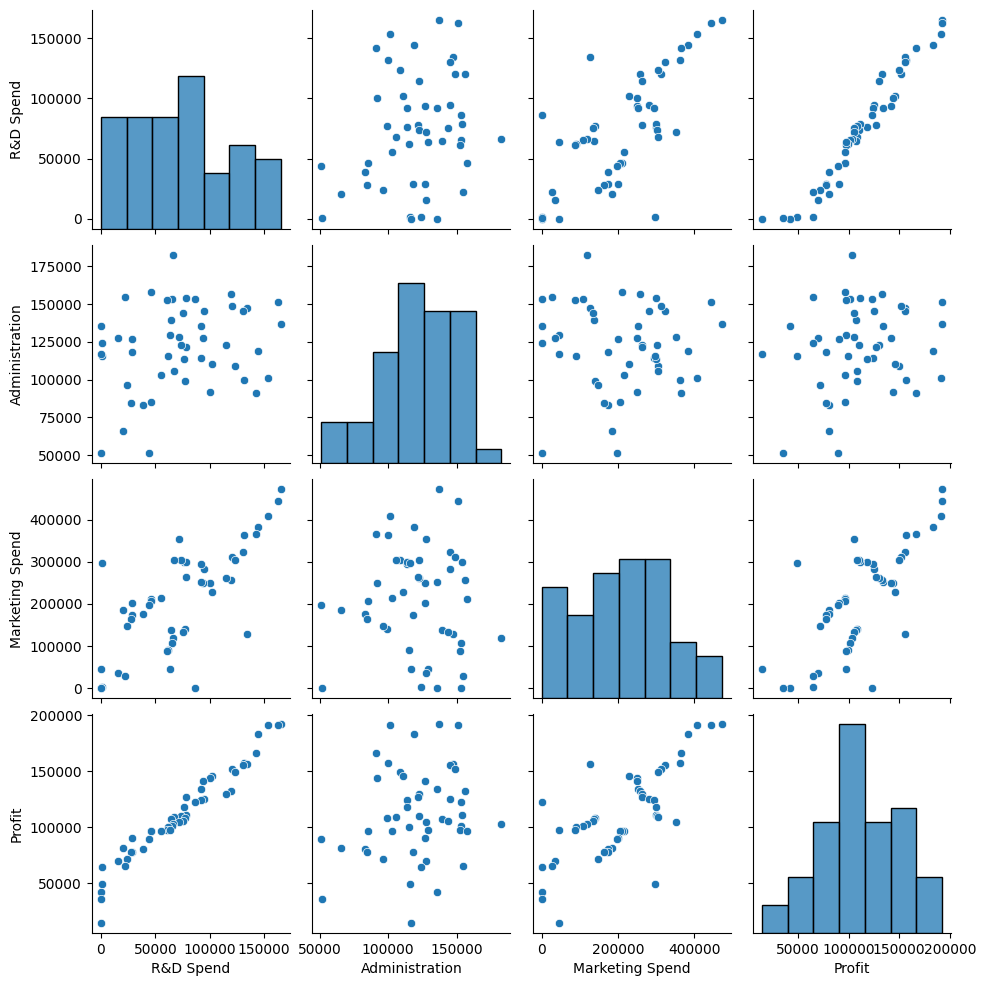

In [6]:
# Scatter plots
sns.pairplot(df)
plt.savefig("startup_graphs/pairplot.png")
plt.show()

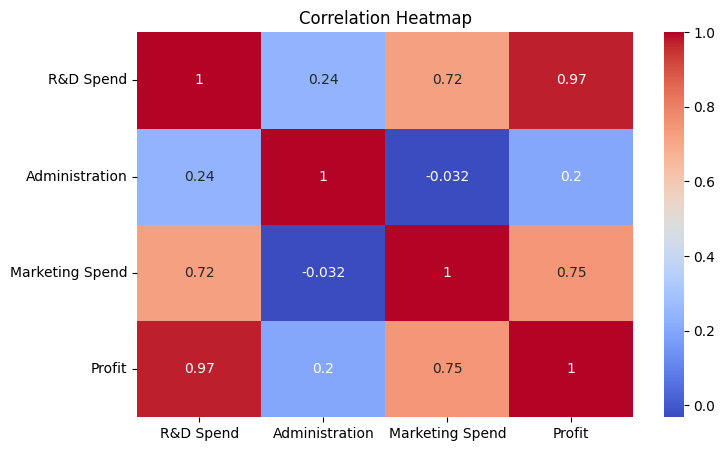

In [7]:
# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("startup_graphs/heatmap.png")
plt.show()

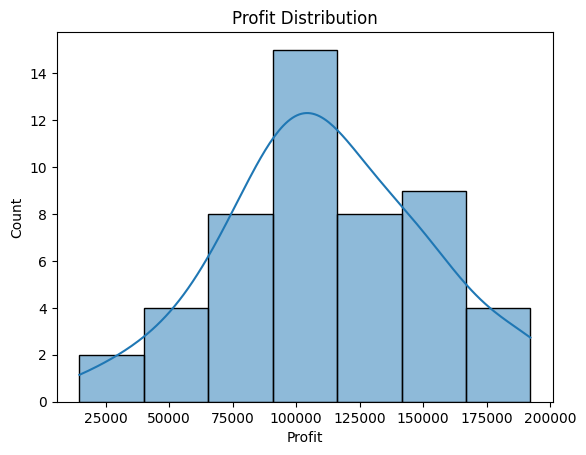

In [8]:
# Profit distribution
plt.figure()
sns.histplot(df["Profit"], kde=True)
plt.title("Profit Distribution")
plt.savefig("startup_graphs/profit_hist.png")
plt.show()

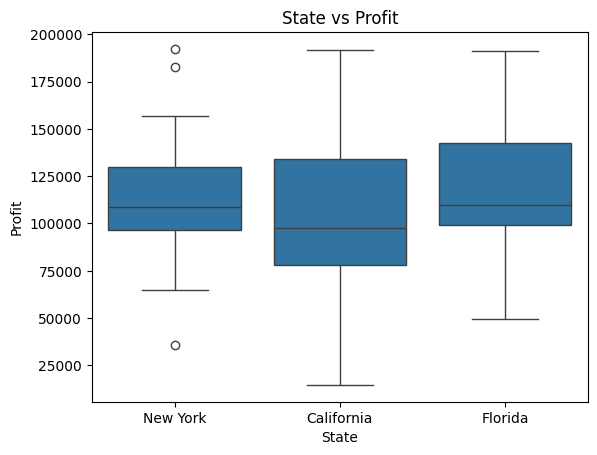

In [9]:
# Boxplot (State vs Profit)
plt.figure()
sns.boxplot(x=df["State"], y=df["Profit"])
plt.title("State vs Profit")
plt.savefig("startup_graphs/state_boxplot.png")
plt.show()


In [10]:
# ==============================================
# INSIGHTS
# ==============================================
print("\nKey Insights:")
print("- R&D Spend has highest impact on Profit")
print("- Marketing Spend has moderate impact")
print("- Administration has low impact")
print("- State has minimal influence\n")



Key Insights:
- R&D Spend has highest impact on Profit
- Marketing Spend has moderate impact
- Administration has low impact
- State has minimal influence



In [11]:
print("Step 5: Data Preprocessing...\n")

df_encoded = pd.get_dummies(df, columns=["State"], drop_first=True)

print("Encoding Done Successfully!")
print(df_encoded.head())

Step 5: Data Preprocessing...

Encoding Done Successfully!
   R&D Spend  Administration  Marketing Spend     Profit  State_Florida  \
0  165349.20       136897.80        471784.10  192261.83          False   
1  162597.70       151377.59        443898.53  191792.06          False   
2  153441.51       101145.55        407934.54  191050.39           True   
3  144372.41       118671.85        383199.62  182901.99          False   
4  142107.34        91391.77        366168.42  166187.94           True   

   State_New York  
0            True  
1           False  
2           False  
3            True  
4           False  


In [12]:
print("\nStep 6: Building Base Model...\n")

X = df_encoded.drop("Profit", axis=1)
y = df_encoded["Profit"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
r2_base = r2_score(y, y_pred)

print(f"Base Model R2 Score: {round(r2_base,4)}")


Step 6: Building Base Model...

Base Model R2 Score: 0.9508


In [13]:
print("\nStep 7: Applying Log Transformation...\n")

df_log = df_encoded.copy()
df_log["Profit"] = np.log(df_log["Profit"])

X_log = df_log.drop("Profit", axis=1)
y_log = df_log["Profit"]

model_log = LinearRegression()
model_log.fit(X_log, y_log)

y_pred_log = np.exp(model_log.predict(X_log))
r2_log = r2_score(df["Profit"], y_pred_log)

print(f"Log Model R2 Score: {round(r2_log,4)}")


Step 7: Applying Log Transformation...

Log Model R2 Score: 0.8538


In [14]:
print("\nStep 8: Applying Square Root Transformation...\n")

df_sqrt = df_encoded.copy()
df_sqrt["Profit"] = np.sqrt(df_sqrt["Profit"])

X_sqrt = df_sqrt.drop("Profit", axis=1)
y_sqrt = df_sqrt["Profit"]

model_sqrt = LinearRegression()
model_sqrt.fit(X_sqrt, y_sqrt)

y_pred_sqrt = (model_sqrt.predict(X_sqrt))**2
r2_sqrt = r2_score(df["Profit"], y_pred_sqrt)

print(f"Sqrt Model R2 Score: {round(r2_sqrt,4)}")



Step 8: Applying Square Root Transformation...

Sqrt Model R2 Score: 0.9335


In [15]:
print("\nStep 9: Comparing Models...\n")

results = pd.DataFrame({
    "Model": ["Base Model", "Log Model", "Sqrt Model"],
    "R2 Score": [round(r2_base,4), round(r2_log,4), round(r2_sqrt,4)]
})

print(results)


Step 9: Comparing Models...

        Model  R2 Score
0  Base Model    0.9508
1   Log Model    0.8538
2  Sqrt Model    0.9335


In [16]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("\nBest Model Selected:")
print(best_model)


Best Model Selected:
Model       Base Model
R2 Score        0.9508
Name: 0, dtype: object
